### EDA & Preprocessing

#### Note: This is using csci1470 Enviornment, plus additional packages

In [ ]:
import pandas as pd
import numpy as np
import openpyxl
# !pip install openpyxl

### Load Data

In [2]:
import pandas as pd
import numpy as np
import openpyxl
import os
import re

In [ ]:
data = pd.read_excel("../data/2013-2023_update.xlsx")

In [4]:
# print column names
print(data.columns)

Index(['url', 'filename', 'year', 'first_partner_name', 'first_partner_age',
       'first_partner_birthplace_location',
       'first_partner_undergraduate_school', 'first_partner_graduate_school',
       'first_partner_major_undergraduate', 'first_partner_major_graduate',
       'first_partner_occupation', 'first_partner_employment',
       'first_partner_employment_location', 'first_partner_gender',
       'first_partner_ethnicity', 'first_partner_residence',
       'first_partner_father_hometown',
       'first_partner_father_undergraduate_school',
       'first_partner_father_graduate_school',
       'first_partner_father_occupation', 'first_partner_father_employment',
       'first_partner_father_marital_status', 'first_partner_mother_hometown',
       'first_partner_mother_undergraduate_school',
       'first_partner_mother_graduate_school',
       'first_partner_mother_occupation', 'first_partner_mother_employment',
       'first_partner_mother_marital_status', 'second_partner_

In [8]:
# Calculate the proportion of missing data for each column
missing_data_proportion = 100 - data.isnull().mean() * 100

# Sort the missing data proportion from high to low
missing_data_proportion_sorted = missing_data_proportion.sort_values(ascending=False)

# Print the sorted missing data proportion
print("Non-Missing Data Proportion (sorted, %):")
missing_data_proportion_sorted [missing_data_proportion_sorted > 50]

Non-Missing Data Proportion (sorted, %):


url                                    100.000000
first_partner_age                      100.000000
filename                               100.000000
second_partner_age                     100.000000
year                                   100.000000
marriage_officiant_name                 98.973687
wedding_venue                           98.908178
second_partner_occupation               97.652582
second_partner_name                     97.608909
second_partner_is_retired               97.466972
second_partner_level                    97.466972
second_partner_is_student               97.466972
marriage_officiant_title                96.844634
first_partner_gender                    96.735451
first_partner_name                      96.724533
first_partner_occupation                95.720057
first_partner_is_retired                95.217819
first_partner_level                     95.217819
first_partner_is_student                95.217819
second_partner_field                    93.623758


In [9]:
data['second_partner_undergraduate_school'].groupby(data['second_partner_undergraduate_school']).count().sort_values(ascending=False).head(50)

second_partner_undergraduate_school
Harvard                               297
University of Pennsylvania            296
Yale                                  252
Cornell                               207
University of Michigan                176
Princeton                             157
Columbia                              132
Georgetown                            132
Dartmouth                             105
Stanford                               95
George Washington University           92
Washington University in St. Louis     90
Duke                                   87
New York University                    87
Boston College                         84
N.Y.U.                                 75
Brown University                       75
University of Virginia                 74
Brown                                  70
Boston University                      68
University of California, Berkeley     66
University of Maryland                 64
Tufts                                  6

In [10]:
data.tail()

,url,filename,year,first_partner_name,first_partner_age,first_partner_birthplace_location,first_partner_undergraduate_school,first_partner_graduate_school,first_partner_major_undergraduate,first_partner_major_graduate,...,first_partner_mother_is_retired,second_partner_is_retired,second_partner_father_is_retired,second_partner_mother_is_retired,first_partner_field,first_partner_father_field,first_partner_mother_field,second_partner_field,second_partner_father_field,second_partner_mother_field
9154,https://www.nytimes.com/article/postpartum-exe...,3c27d6d3-e6c5-5467-8542-f36230b1d309,2023,Samantha Rose Weinstein,30,"New City, N.Y.",Wagner College,NaN,Musical Theater Performance,NaN,...,NaN,0.0,NaN,NaN,Sales Occupations,NaN,NaN,Computer and Information Technology Occupations,NaN,NaN
9155,https://www.nytimes.com/2019/11/15/nyregion/ho...,4f40a40a-233a-5b50-abf6-ea79150a768c,2023,Rebecca Ann Woodfork,42,"Swampscott, Mass.",Learning Institute of Beauty Sciences,NaN,NaN,NaN,...,NaN,0.0,NaN,NaN,Arts and Design Occupations,NaN,NaN,Sales Occupations,NaN,NaN
9156,https://www.nytimes.com/2023/07/14/arts/music/...,824bbba1-91d6-5445-81e5-3dacb4227029,2023,Andrew Shepard Markoff,31,NaN,Georgetown,NaN,International History,NaN,...,NaN,0.0,NaN,NaN,Business and Financial Occupations,NaN,NaN,Legal Occupations,NaN,NaN
9157,https://www.nytimes.com/interactive/2023/04/14...,07d469af-2988-5b51-813d-c408a1413408,2023,Kelley Louise Carter,46,NaN,Michigan State University,NaN,NaN,NaN,...,NaN,0.0,NaN,NaN,Media and Communication Occupations,NaN,NaN,"Life, Physical, and Social Science Occupations",NaN,NaN
9158,https://www.nytimes.com/2020/01/17/theater/und...,8ffa5482-d1b5-5453-936b-d1a656622420,2023,Amrit Malothra,31,Washington D.C.,University of Pennsylvania,M.I.T. Sloan School of Management,Economics,NaN,...,NaN,0.0,NaN,NaN,Business and Financial Occupations,NaN,NaN,Business and Financial Occupations,NaN,NaN


In [11]:
# data_demo = data[['first_partner_gender', 'first_partner_age','first_partner_undergraduate_school','first_partner_occupation','first_partner_employment',
#                   'second_partner_gender','second_partner_age','second_partner_occupation','second_partner_undergraduate_school','second_partner_occupation','second_partner_employment']].copy()

data_demo = data[['first_partner_gender', 'first_partner_age','first_partner_undergraduate_school',
                  'second_partner_gender','second_partner_age','second_partner_undergraduate_school']].copy()



In [12]:
data_demo

,first_partner_gender,first_partner_age,first_partner_undergraduate_school,second_partner_gender,second_partner_age,second_partner_undergraduate_school
0,Female,31,Tufts,Male,32,Bowdoin College
1,Female,30,Yale,NaN,30,Yale
2,Female,28,George Washington University,Male,35,Washington University in St. Louis
3,Female,34,University of Florida,Male,43,University of Miami
4,Female,27,Boston University,Male,33,University of Pennsylvania
...,...,...,...,...,...,...
9154,Female,30,Wagner College,Male,31,Wagner College
9155,Female,42,Learning Institute of Beauty Sciences,Female,50,Bowling Green State University
9156,Male,31,Georgetown,Female,33,Northwestern
9157,Female,46,Michigan State University,Male,42,Lane College


In [13]:
# write me the code that output the unique values in the first_partner_undergraduate_school
for i in data_demo['first_partner_undergraduate_school'].unique():
    print(i)

Tufts
Yale
George Washington University
University of Florida
Boston University
Fordham
Rutgers
University of Exeter
Loyola University New Orleans
Binghamton University
Cornell
Georgetown
nan
Harvard
New York University
Northwestern
Columbia
Cornell University
University of Victoria
Johns Hopkins
Villanova University
Northeastern University
Trinity College in Hartford
Muhlenberg College
Indiana University
West Virginia University
Denison University
Princeton
Emory
University of California, Berkeley
Duke
Wellesley
Lehigh University
University of Michigan
University of Birmingham
Brown
University of Minnesota
Hamilton College
American Academy of Dramatic Arts in Los Angeles
University of Connecticut
Rider University
University of Pennsylvania
Drake University
Bowdoin College
Pitzer College
University of Tennessee
Northwestern University
University of Alabama
University of Maryland
University of Miami
University of Central Florida
Dartmouth
Lafayette College
Rollins College
Swarthmore Col

In [14]:
school_list = list(set([s for s in data_demo['first_partner_undergraduate_school'].unique()]))

# Define the classification function
def classify_school(school_name):
    name = school_name.lower()
    if any(kw in name for kw in ['harvard', 'yale', 'princeton', 'mit', 'columbia', 'stanford', 'upenn', 'dartmouth', 'brown']):
        return "Ivy League / Elite Private"
    elif any(kw in name for kw in ['amherst', 'swarthmore', 'williams', 'pomona', 'bowdoin', 'middlebury', 'vassar', 'wesleyan', 'grinnell', 'colby', 'oberlin', 'smith', 'haverford', 'carleton', 'bates', 'reed', 'colgate', 'hamilton']):
        return "Highly Selective Liberal Arts"
    elif any(kw in name for kw in ['university of california', 'uc berkeley', 'michigan', 'virginia', 'illinois', 'washington', 'wisconsin', 'texas', 'georgia']):
        return "Top Public / Flagship State"
    elif any(kw in name for kw in ['oxford', 'cambridge', 'toronto', 'mcgill', 'sorbonne', 'sciences po', 'british columbia', 'exeter']):
        return "International University"
    elif any(kw in name for kw in ['institute of technology', 'school of music', 'college of art', 'design', 'conservatory', 'parsons']):
        return "Specialized / Arts / Other"
    else:
        return "Other U.S. Universities"

# Apply classification
school_df = pd.DataFrame({'school_name': school_list})

In [15]:

for i in school_list:
    if not isinstance(i, float):
        cat = classify_school(i)
        school_df = pd.concat([school_df, pd.DataFrame({'school_name': [i], 'category': [cat]})], ignore_index=True)
# Remove duplicates
school_df = school_df.drop_duplicates(subset=['school_name'],keep='last')
# Reset index
school_df = school_df.reset_index(drop=True)
# Print the DataFrame
print(school_df)


                                    school_name                    category
0                                           NaN                         NaN
1     School of Hotel Administration at Cornell     Other U.S. Universities
2                                     Dartmouth  Ivy League / Elite Private
3                     State College at Purchase     Other U.S. Universities
4                            Irving High School     Other U.S. Universities
...                                         ...                         ...
1164                California State University     Other U.S. Universities
1165                  Nyack College in New York     Other U.S. Universities
1166                      University of Chicago     Other U.S. Universities
1167                        CUNY’s York College     Other U.S. Universities
1168             University of Colorado Boulder     Other U.S. Universities

[1169 rows x 2 columns]


In [16]:
# check which one is flow object in the school_df
school_df

,school_name,category
0,NaN,NaN
1,School of Hotel Administration at Cornell,Other U.S. Universities
2,Dartmouth,Ivy League / Elite Private
3,State College at Purchase,Other U.S. Universities
4,Irving High School,Other U.S. Universities
...,...,...
1164,California State University,Other U.S. Universities
1165,Nyack College in New York,Other U.S. Universities
1166,University of Chicago,Other U.S. Universities
1167,CUNY’s York College,Other U.S. Universities


In [17]:
school_category_map = dict(zip(school_df['school_name'], school_df['category']))

# Function to map school name to category using the dictionary (with fallback)
def map_school_to_category(school_name):
    if pd.isna(school_name):
        return "Unknown"
    return school_category_map.get(school_name.strip(), "Other / Unknown")


# Apply the mapping function
data_demo['first_partner_school_category'] = data_demo['first_partner_undergraduate_school'].apply(map_school_to_category)
data_demo['second_partner_school_category'] = data_demo['second_partner_undergraduate_school'].apply(map_school_to_category)



In [18]:
data_demo.drop(columns=['first_partner_undergraduate_school','second_partner_undergraduate_school'], inplace=True)
data_demo

,first_partner_gender,first_partner_age,second_partner_gender,second_partner_age,first_partner_school_category,second_partner_school_category
0,Female,31,Male,32,Other U.S. Universities,Highly Selective Liberal Arts
1,Female,30,NaN,30,Ivy League / Elite Private,Ivy League / Elite Private
2,Female,28,Male,35,Top Public / Flagship State,Top Public / Flagship State
3,Female,34,Male,43,Other U.S. Universities,Other U.S. Universities
4,Female,27,Male,33,Other U.S. Universities,Other U.S. Universities
...,...,...,...,...,...,...
9154,Female,30,Male,31,Other U.S. Universities,Other U.S. Universities
9155,Female,42,Female,50,Other U.S. Universities,Other U.S. Universities
9156,Male,31,Female,33,Other U.S. Universities,Other U.S. Universities
9157,Female,46,Male,42,Top Public / Flagship State,Other / Unknown


In [19]:
# show the min and max age of first_partner_age
print("Min age of first partner: ", data_demo['first_partner_age'].min())
print("Max age of first partner: ", data_demo['first_partner_age'].max())

Min age of first partner:  12
Max age of first partner:  Not mentioned


In [20]:
data_demo.to_excel('Data/data_demo.xlsx', index=False)

# Same-gender Couples

In [ ]:
# 2013-2023_update.xlsx
first_gender_col = 'first_partner_gender'
second_gender_col = 'second_partner_gender'
df_clean = data.dropna(subset=[first_gender_col, second_gender_col])

same_gender = df_clean[first_gender_col] == df_clean[second_gender_col]

same_gender_couples = df_clean[same_gender]


gay_couples = same_gender_couples[same_gender_couples[first_gender_col] == 'Male']
lesbian_couples = same_gender_couples[same_gender_couples[first_gender_col] == 'Female']

print(f"Total same-gender couples: {len(same_gender_couples)}")
print(f" - Gay couples (Male-Male): {len(gay_couples)}")
print(f" - Lesbian couples (Female-Female): {len(lesbian_couples)}")

total_couples = len(df_clean)
print(f"\nProportion of same-gender couples: {len(same_gender_couples) / total_couples:.2%}")
print(f"Proportion of gay couples: {len(gay_couples) / total_couples:.2%}")
print(f"Proportion of lesbian couples: {len(lesbian_couples) / total_couples:.2%}")

Total same-gender couples: 787
 - Gay couples (Male-Male): 452
 - Lesbian couples (Female-Female): 269

Proportion of same-gender couples: 9.74%
Proportion of gay couples: 5.60%
Proportion of lesbian couples: 3.33%


In [14]:
df = pd.read_excel("../data/data_final.xlsx")
df.head()

,url,filename,first_partner_gender,first_partner_age_bin,second_partner_gender,second_partner_age_bin,first_partner_school_category,second_partner_school_category,first_partner_level_id,second_partner_level_id,first_partner_field,second_partner_field
0,https://www.nytimes.com/2015/01/11/fashion/wed...,f657c24a-6a56-5ca4-b97f-088c31f8e0bb,Female,30-34,Male,30-34,Top 50 Private (Non-Ivy),Top 50 Private (Non-Ivy),S4,NaN,Architecture and Engineering Occupations,NaN
1,https://www.nytimes.com/2015/08/02/fashion/wed...,def8fbc6-6199-520e-be42-42ecf6f1a26b,Female,30-34,NaN,30-34,Ivy League,Ivy League,S5,S5,Management Occupations,Architecture and Engineering Occupations
2,https://www.nytimes.com/2015/06/14/fashion/wed...,1e99518c-5fe6-59a2-a4a6-9b9d91afcf3b,Female,25-29,Male,35-39,Other Colleges,Top 50 Private (Non-Ivy),S4,S5,Healthcare Occupations,Healthcare Occupations
3,https://www.nytimes.com/2015/02/22/fashion/wed...,6cf6a025-0b2b-5d90-b51f-660af4435824,Female,30-34,Male,40-44,Top 30 Public,Other Colleges,S5,S3,Management Occupations,Sales Occupations
4,https://www.nytimes.com/2015/09/13/fashion/wed...,02e3808c-b94f-5635-84c6-71d9ab1e47ea,Female,25-29,Male,30-34,Other Colleges,Ivy League,S5,S4,Arts and Design Occupations,Management Occupations


In [17]:
first_gender_col = 'first_partner_gender'
second_gender_col = 'second_partner_gender'

df_clean = df.dropna(subset=[first_gender_col, second_gender_col])

same_gender = df_clean[first_gender_col] == df_clean[second_gender_col]
same_gender_couples = df_clean[same_gender]

gay_couples = same_gender_couples[same_gender_couples[first_gender_col] == 'Male']
lesbian_couples = same_gender_couples[same_gender_couples[first_gender_col] == 'Female']


print(f"Total same-gender couples: {len(same_gender_couples)}")
print(f" - Gay couples (Male-Male): {len(gay_couples)}")
print(f" - Lesbian couples (Female-Female): {len(lesbian_couples)}")


total_couples = len(df_clean)
print(f"\nProportion of same-gender couples: {len(same_gender_couples) / total_couples:.2%}")
print(f"Proportion of gay couples: {len(gay_couples) / total_couples:.2%}")
print(f"Proportion of lesbian couples: {len(lesbian_couples) / total_couples:.2%}")

Total same-gender couples: 788
 - Gay couples (Male-Male): 452
 - Lesbian couples (Female-Female): 269

Proportion of same-gender couples: 9.76%
Proportion of gay couples: 5.60%
Proportion of lesbian couples: 3.33%


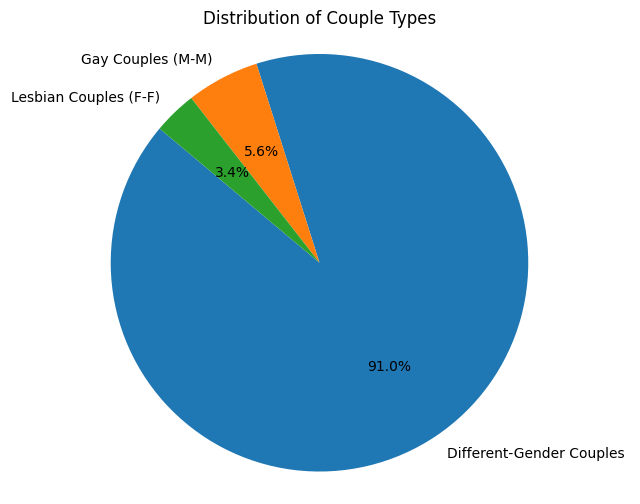

In [ ]:
import matplotlib.pyplot as plt

same_gender_count = len(same_gender_couples)
gay_couples_count = len(gay_couples)
lesbian_couples_count = len(lesbian_couples)
total_couples_count = len(df_clean)
different_gender_count = total_couples_count - same_gender_count


labels = ['Different-Gender Couples', 'Gay Couples (M-M)', 'Lesbian Couples (F-F)']
sizes = [different_gender_count, gay_couples_count, lesbian_couples_count]

plt.figure(figsize=(8, 6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140)
plt.title('Distribution of Couple Types')
plt.axis('equal')  
plt.show()